# Data Injection #
**Description**
This Jupyter notebook is used to inject Data in excel or CSV format into firebase DB 

In [1]:

!pip install pandas --quiet
!pip install geopy --quiet

In [2]:
import pandas as pd
data_path = './dataset'

## Load the Transport Cost Data


In [3]:
transportcost_path = f"{data_path}/TransportCosts.csv"
df_transport_cost = pd.read_csv(transportcost_path)
df_transport_cost.tail()

df_list=[]

for col in df_transport_cost.columns:
    if "Perunit_freight_rate_USkg_Value" in col:
        year = col.split('_')[0]
        df_tmp = df_transport_cost[["Destination_Label","Origin_Label", "Product_Code", "Product_Label", col]].copy()
        df_tmp.rename(columns={col: "Perunit_freight_rate_USkg_Value"}, inplace=True)
        df_tmp["Year"] = year
        df_list.append(df_tmp)

df_transport_cost_combined = pd.concat(df_list, ignore_index=True).reset_index(drop=True)
df_transport_cost_combined.tail()

,Destination_Label,Origin_Label,Product_Code,Product_Label,Perunit_freight_rate_USkg_Value,Year
375517,Zimbabwe,Zambia,2106,Food preparations not elsewhere specified or i...,0.299,2021
375518,Zimbabwe,Zambia,3304,"Cosmetic and toilet preparations; beauty, make...",0.170,2021
375519,Zimbabwe,Zambia,6109,"T-shirts, singlets and other vests; knitted or...",NaN,2021
375520,Zimbabwe,Zambia,8517,"Telephone sets, including telephones for cellu...",6.148,2021
375521,Zimbabwe,Zambia,9404,Mattress supports; articles of bedding (e.g. m...,2.613,2021


## Load CPI data by source and destination country

In [4]:
cpi_data_path = f"{data_path}/CPI.csv"
df_cpi = pd.read_csv(cpi_data_path)
df_cpi.head()
# df_cpi[df_cpi["Economy_Label"] != "Individual economies"]
df_cpi = df_cpi[df_cpi["Economy_Label"] != "Individual economies"]
df_cpi.head()

# df_combined = pd.merge(df_transport_cost_combined.copy(), df_cpi[["Economy_Label", "Year", "Annual_average_growth_rate_Value"]].copy(), left_on=["Origin_Label", "Year"], right_on=["Economy_Label", "Year"], how="left")
# df_combined 


df_transport_cost_combined["Year"] = df_transport_cost_combined["Year"].astype(str)
df_cpi["Year"] = df_cpi["Year"].astype(str)

df_combined = pd.merge(
    df_transport_cost_combined.copy(),
    df_cpi[["Economy_Label", "Year", "Annual_average_growth_rate_Value"]].copy(),
    left_on=["Origin_Label", "Year"],
    right_on=["Economy_Label", "Year"],
    how="left"
)

df_combined.rename(columns={"Annual_average_growth_rate_Value": "Source_CPI_Annual_average_growth_rate_Value"}, inplace=True)
df_combined.drop(columns=["Economy_Label"], inplace=True)
df_combined.head()
df_combined = pd.merge(
    df_combined,
    df_cpi[["Economy_Label", "Year", "Annual_average_growth_rate_Value"]].copy(),
    left_on=["Destination_Label", "Year"],
    right_on=["Economy_Label", "Year"],
    how="left"
)
df_combined.rename(columns={"Annual_average_growth_rate_Value": "Destination_CPI_Annual_average_growth_rate_Value"}, inplace=True)
df_combined.drop(columns=["Economy_Label"], inplace=True)

df_combined.head()

,Destination_Label,Origin_Label,Product_Code,Product_Label,Perunit_freight_rate_USkg_Value,Year,Source_CPI_Annual_average_growth_rate_Value,Destination_CPI_Annual_average_growth_rate_Value
0,Afghanistan,Aruba,8517,"Telephone sets, including telephones for cellu...",NaN,2016,-0.93,2.12
1,Afghanistan,Australia,8517,"Telephone sets, including telephones for cellu...",NaN,2016,1.28,2.12
2,Afghanistan,Austria,8517,"Telephone sets, including telephones for cellu...",NaN,2016,0.97,2.12
3,Afghanistan,Belgium,2106,Food preparations not elsewhere specified or i...,0.227,2016,1.77,2.12
4,Afghanistan,Belgium,8517,"Telephone sets, including telephones for cellu...",NaN,2016,1.77,2.12


## Load GDP data by source and destination country

In [5]:
gdp_data_path = f"{data_path}/GDP.csv"
df_gdp = pd.read_csv(gdp_data_path)
df_gdp.head()
# df_gdp[df_gdp["Economy_Label"] != "Individual economies"]
df_gdp = df_gdp[df_gdp["Economy_Label"] != "Individual economies"]
df_gdp["Year"] = df_gdp["Year"].astype(str)

df_combined = pd.merge(
    df_combined.copy(),
    df_gdp[["Economy_Label", "Year", "US_at_current_prices_in_millions_Value"]].copy(),
    left_on=["Origin_Label", "Year"],
    right_on=["Economy_Label", "Year"],
    how="left"
)

df_combined.rename(columns={"US_at_current_prices_in_millions_Value": "Source_GDP_US_at_current_prices_in_millions_Value"}, inplace=True)
df_combined.drop(columns=["Economy_Label"], inplace=True)
df_combined.head()
df_combined = pd.merge(
    df_combined.copy(),
    df_gdp[["Economy_Label", "Year", "US_at_current_prices_in_millions_Value"]].copy(),
    left_on=["Destination_Label", "Year"],
    right_on=["Economy_Label", "Year"],
    how="left"
)
df_combined.rename(columns={"US_at_current_prices_in_millions_Value": "Destination_GDP_US_at_current_prices_in_millions_Value"}, inplace=True)
df_combined.drop(columns=["Economy_Label"], inplace=True)

df_combined.head()



,Destination_Label,Origin_Label,Product_Code,Product_Label,Perunit_freight_rate_USkg_Value,Year,Source_CPI_Annual_average_growth_rate_Value,Destination_CPI_Annual_average_growth_rate_Value,Source_GDP_US_at_current_prices_in_millions_Value,Destination_GDP_US_at_current_prices_in_millions_Value
0,Afghanistan,Aruba,8517,"Telephone sets, including telephones for cellu...",NaN,2016,-0.93,2.12,2984.0,18224.0
1,Afghanistan,Australia,8517,"Telephone sets, including telephones for cellu...",NaN,2016,1.28,2.12,1306599.0,18224.0
2,Afghanistan,Austria,8517,"Telephone sets, including telephones for cellu...",NaN,2016,0.97,2.12,393687.0,18224.0
3,Afghanistan,Belgium,2106,Food preparations not elsewhere specified or i...,0.227,2016,1.77,2.12,474272.0,18224.0
4,Afghanistan,Belgium,8517,"Telephone sets, including telephones for cellu...",NaN,2016,1.77,2.12,474272.0,18224.0


## Load GNI data by source and destination country

In [6]:
gni_data_path = f"{data_path}/GNI.csv"
df_gni = pd.read_csv(gni_data_path)
df_gni.head()
# df_gni[df_gni["Economy_Label"] != "Individual economies"]
df_gni = df_gni[df_gni["Economy_Label"] != "Individual economies"]
df_gni["Year"] = df_gni["Year"].astype(str)
df_gni.head()
df_combined = pd.merge(
    df_combined.copy(),
    df_gni[["Economy_Label", "Year", "US_dollars_at_current_prices_in_millions_Value"]].copy(),
    left_on=["Origin_Label", "Year"],
    right_on=["Economy_Label", "Year"],
    how="left"
)

df_combined.rename(columns={"US_dollars_at_current_prices_in_millions_Value": "Source_GNI_US_dollars_at_current_prices_in_millions_Value"}, inplace=True)
df_combined.drop(columns=["Economy_Label"], inplace=True)
df_combined.head()
df_combined = pd.merge(
    df_combined.copy(),
    df_gni[["Economy_Label", "Year", "US_dollars_at_current_prices_in_millions_Value"]].copy(),
    left_on=["Destination_Label", "Year"],
    right_on=["Economy_Label", "Year"],
    how="left"
)
df_combined.rename(columns={"US_dollars_at_current_prices_in_millions_Value": "Destination_GNI_US_dollars_at_current_prices_in_millions_Value"}, inplace=True)
df_combined.drop(columns=["Economy_Label"], inplace=True)

df_combined.head()



,Destination_Label,Origin_Label,Product_Code,Product_Label,Perunit_freight_rate_USkg_Value,Year,Source_CPI_Annual_average_growth_rate_Value,Destination_CPI_Annual_average_growth_rate_Value,Source_GDP_US_at_current_prices_in_millions_Value,Destination_GDP_US_at_current_prices_in_millions_Value,Source_GNI_US_dollars_at_current_prices_in_millions_Value,Destination_GNI_US_dollars_at_current_prices_in_millions_Value
0,Afghanistan,Aruba,8517,"Telephone sets, including telephones for cellu...",NaN,2016,-0.93,2.12,2984.0,18224.0,2848.0,18199.0
1,Afghanistan,Australia,8517,"Telephone sets, including telephones for cellu...",NaN,2016,1.28,2.12,1306599.0,18224.0,1274452.0,18199.0
2,Afghanistan,Austria,8517,"Telephone sets, including telephones for cellu...",NaN,2016,0.97,2.12,393687.0,18224.0,395539.0,18199.0
3,Afghanistan,Belgium,2106,Food preparations not elsewhere specified or i...,0.227,2016,1.77,2.12,474272.0,18224.0,480303.0,18199.0
4,Afghanistan,Belgium,8517,"Telephone sets, including telephones for cellu...",NaN,2016,1.77,2.12,474272.0,18224.0,480303.0,18199.0


## Load LSBCI data by source and destination country

In [7]:
lsbci_data_path = f"{data_path}/LSBCI.csv"
df_lsbci = pd.read_csv(lsbci_data_path)

df_lsbci["Year"] = df_lsbci["Quarter"].str.split("Q").str[0]
df_lsbci.loc[df_lsbci["Economy Label"] == "United States", "Economy Label"] = "United States of America"
df_lsbci.loc[df_lsbci["Partner Label"] == "United States", "Partner Label"] = "United States of America"
df_combined = pd.merge(
    df_combined.copy(),
    df_lsbci[["Economy Label", "Year", "Partner Label", "Index"]].copy(),
    left_on=["Origin_Label", "Year", "Destination_Label"],
    right_on=["Economy Label", "Year", "Partner Label"],
    how="left"
)

df_combined = df_combined.drop(columns=["Economy Label", "Partner Label"])


df_combined.head()


,Destination_Label,Origin_Label,Product_Code,Product_Label,Perunit_freight_rate_USkg_Value,Year,Source_CPI_Annual_average_growth_rate_Value,Destination_CPI_Annual_average_growth_rate_Value,Source_GDP_US_at_current_prices_in_millions_Value,Destination_GDP_US_at_current_prices_in_millions_Value,Source_GNI_US_dollars_at_current_prices_in_millions_Value,Destination_GNI_US_dollars_at_current_prices_in_millions_Value,Index
0,Afghanistan,Aruba,8517,"Telephone sets, including telephones for cellu...",NaN,2016,-0.93,2.12,2984.0,18224.0,2848.0,18199.0,NaN
1,Afghanistan,Australia,8517,"Telephone sets, including telephones for cellu...",NaN,2016,1.28,2.12,1306599.0,18224.0,1274452.0,18199.0,NaN
2,Afghanistan,Austria,8517,"Telephone sets, including telephones for cellu...",NaN,2016,0.97,2.12,393687.0,18224.0,395539.0,18199.0,NaN
3,Afghanistan,Belgium,2106,Food preparations not elsewhere specified or i...,0.227,2016,1.77,2.12,474272.0,18224.0,480303.0,18199.0,NaN
4,Afghanistan,Belgium,8517,"Telephone sets, including telephones for cellu...",NaN,2016,1.77,2.12,474272.0,18224.0,480303.0,18199.0,NaN


In [8]:
df_combined.shape
df_combined.to_csv(f"{data_path}/combined_dataset.csv", index=False)

In [9]:
print(len(df_lsbci["Partner Label"].unique()))
df_lsbci.head()
print(len(df_combined["Origin_Label"].unique()))
# df_lsbci.loc[df_lsbci["Economy Label"] == "United States", "Economy Label"] = "United States of America"
# df_lsbci.loc[df_lsbci["Partner Label"] == "United States", "Partner Label"] = "United States of America"
# df_lsbci.loc[df_lsbci["Partner Label"] == "United States", "Partner Label"] = "United States of America"
print("in lsbci but not in combined:", set(df_lsbci["Economy Label"].unique()) - set(df_combined["Origin_Label"].unique()))
print("in combined but not in lsbci:", set(df_combined["Origin_Label"].unique()) - set(df_lsbci["Economy Label"].unique()))
list_of_countries_in_lsbci =  (set(df_combined["Origin_Label"].unique()) | set(df_combined["Destination_Label"].unique()))
# df_lsbci["Partner Label"].unique()
print(list_of_countries_in_lsbci)

191
222
in lsbci but not in combined: {'French Guiana', 'Republic of Moldova', 'Sudan (...2011)', 'Reunion', 'Netherlands Antilles', 'Republic of Korea', 'Puerto Rico', 'Congo', "Dem. People's Rep. of Korea", 'Martinique', 'Dem. Rep. of the Congo', 'Guernsey', 'United Republic of Tanzania', 'Cocos (Keeling) Islands', 'United States Virgin Islands', 'Mayotte', 'Serbia and Montenegro', 'Wallis and Futuna Islands', 'Jersey', 'Guadeloupe'}
in combined but not in lsbci: {'Chad', 'South Sudan', 'Rwanda', 'Azerbaijan', 'Austria', 'Burundi', 'Luxembourg', 'State of Palestine', 'Zimbabwe', 'Mali', 'Moldova, Republic of', 'Mongolia', 'Hungary', 'Switzerland, Liechtenstein', 'Czechia', 'Tokelau', 'Uganda', 'Malawi', 'Kyrgyzstan', 'Tajikistan', 'Saint Barthelemy', 'Nepal', 'China, Macao SAR', 'San Marino', 'Central African Republic', 'Belarus', "Lao People's Dem. Rep.", "Korea, Dem. People's Rep. of", 'Bhutan', 'Tanzania, United Republic of', 'Niger', 'Andorra', 'Burkina Faso', 'Kazakhstan', 'Kore

In [10]:
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut, GeocoderUnavailable
import time

geolocator = Nominatim(user_agent="my_project_app", timeout=10)

# Turn the set into a sorted list and DataFrame
df_countries = pd.DataFrame(
    sorted(list_of_countries_in_lsbci),
    columns=["Country"]
)

def geocode_country(country):
    try:
        loc = geolocator.geocode(country)
        time.sleep(1)
        if loc:
            print(f"OK: {country} -> ({loc.latitude}, {loc.longitude})")
            return pd.Series({"Lat": loc.latitude, "Lon": loc.longitude})
        else:
            print(f"NOT FOUND: {country}")
            return pd.Series({"Lat": None, "Lon": None})
    except (GeocoderTimedOut, GeocoderUnavailable) as e:
        print(f"ERROR: {country} -> {e}")
        return pd.Series({"Lat": None, "Lon": None})

df_countries[["Lat", "Lon"]] = df_countries["Country"].apply(geocode_country)

# Save to CSV in the required format
df_countries.to_csv(f"{data_path}/country_centroids.csv", index=False)
print(f"\nSaved {len(df_countries)} countries to country_centroids.csv")
df_countries


OK: Afghanistan -> (33.7680065, 66.2385139)
OK: Albania -> (41.000028, 19.9999619)
OK: Algeria -> (28.0000272, 2.9999825)
OK: American Samoa -> (-14.297124, -170.7131481)
OK: Andorra -> (42.5407167, 1.5732033)
OK: Angola -> (-11.8775768, 17.5691241)
OK: Anguilla -> (18.1954947, -63.0750234)
OK: Antigua and Barbuda -> (17.2234721, -61.9554608)
OK: Argentina -> (-34.9964963, -64.9672817)
OK: Armenia -> (40.7696272, 44.6736646)
OK: Aruba -> (12.5013629, -69.9618475)
OK: Australia -> (-24.7761086, 134.755)
OK: Austria -> (47.59397, 14.12456)
OK: Azerbaijan -> (40.3936294, 47.7872508)
OK: Bahamas -> (24.7736546, -78.0000547)
OK: Bahrain -> (26.1551249, 50.5344606)
OK: Bangladesh -> (24.4769288, 90.2934413)
OK: Barbados -> (13.1500331, -59.5250305)
OK: Belarus -> (53.4250605, 27.6971358)
OK: Belgium -> (50.6402809, 4.6667145)
OK: Belize -> (17.1204943, -88.6859028)
OK: Benin -> (9.5293472, 2.2584408)
OK: Bermuda -> (32.3040273, -64.7563086)
OK: Bhutan -> (27.549511, 90.5119273)
OK: Bolivia (

,Country,Lat,Lon
0,Afghanistan,33.768006,66.238514
1,Albania,41.000028,19.999962
2,Algeria,28.000027,2.999983
3,American Samoa,-14.297124,-170.713148
4,Andorra,42.540717,1.573203
...,...,...,...
217,Viet Nam,15.926666,107.965086
218,Western Sahara,24.179732,-13.766785
219,Yemen,16.347124,47.891527
220,Zambia,-14.518912,27.558988


In [11]:
from geopy.distance import geodesic

# Load centroids
centroids = pd.read_csv(f"{data_path}/country_centroids.csv")

# Merge for origin
df_combined = df_combined.merge(
    centroids.rename(columns={"Country": "Origin_Label",
                              "Lat": "Origin_Lat",
                              "Lon": "Origin_Lon"}),
    on="Origin_Label",
    how="left"
)

# Merge for destination
df_combined = df_combined.merge(
    centroids.rename(columns={"Country": "Destination_Label",
                              "Lat": "Dest_Lat",
                              "Lon": "Dest_Lon"}),
    on="Destination_Label",
    how="left"
)

# Compute distance without any geocoding API calls
def row_distance(row):
    if pd.isna(row["Origin_Lat"]) or pd.isna(row["Dest_Lat"]):
        return None
    c1 = (row["Origin_Lat"], row["Origin_Lon"])
    c2 = (row["Dest_Lat"], row["Dest_Lon"])
    return geodesic(c1, c2).kilometers

df_combined["Geographical Distance"] = df_combined.apply(row_distance, axis=1)

In [12]:
df_combined

,Destination_Label,Origin_Label,Product_Code,Product_Label,Perunit_freight_rate_USkg_Value,Year,Source_CPI_Annual_average_growth_rate_Value,Destination_CPI_Annual_average_growth_rate_Value,Source_GDP_US_at_current_prices_in_millions_Value,Destination_GDP_US_at_current_prices_in_millions_Value,Source_GNI_US_dollars_at_current_prices_in_millions_Value,Destination_GNI_US_dollars_at_current_prices_in_millions_Value,Index,Origin_Lat,Origin_Lon,Dest_Lat,Dest_Lon,Geographical Distance
0,Afghanistan,Aruba,8517,"Telephone sets, including telephones for cellu...",NaN,2016,-0.93,2.12,2984.0,18224.0,2848.0,18199.0,NaN,12.501363,-69.961848,33.768006,66.238514,13108.322432
1,Afghanistan,Australia,8517,"Telephone sets, including telephones for cellu...",NaN,2016,1.28,2.12,1306599.0,18224.0,1274452.0,18199.0,NaN,-24.776109,134.755000,33.768006,66.238514,9717.453269
2,Afghanistan,Austria,8517,"Telephone sets, including telephones for cellu...",NaN,2016,0.97,2.12,393687.0,18224.0,395539.0,18199.0,NaN,47.593970,14.124560,33.768006,66.238514,4568.800526
3,Afghanistan,Belgium,2106,Food preparations not elsewhere specified or i...,0.227,2016,1.77,2.12,474272.0,18224.0,480303.0,18199.0,NaN,50.640281,4.666715,33.768006,66.238514,5248.382269
4,Afghanistan,Belgium,8517,"Telephone sets, including telephones for cellu...",NaN,2016,1.77,2.12,474272.0,18224.0,480303.0,18199.0,NaN,50.640281,4.666715,33.768006,66.238514,5248.382269
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
375517,Zimbabwe,Zambia,2106,Food preparations not elsewhere specified or i...,0.299,2021,22.02,98.55,22096.0,36001.0,NaN,NaN,NaN,-14.518912,27.558988,-18.455496,29.746841,494.289692
375518,Zimbabwe,Zambia,3304,"Cosmetic and toilet preparations; beauty, make...",0.170,2021,22.02,98.55,22096.0,36001.0,NaN,NaN,NaN,-14.518912,27.558988,-18.455496,29.746841,494.289692
375519,Zimbabwe,Zambia,6109,"T-shirts, singlets and other vests; knitted or...",NaN,2021,22.02,98.55,22096.0,36001.0,NaN,NaN,NaN,-14.518912,27.558988,-18.455496,29.746841,494.289692
375520,Zimbabwe,Zambia,8517,"Telephone sets, including telephones for cellu...",6.148,2021,22.02,98.55,22096.0,36001.0,NaN,NaN,NaN,-14.518912,27.558988,-18.455496,29.746841,494.289692


# Freight Rate Forecasting — XGBoost & Temporal Fusion Transformer (TFT)

**Target:** `Perunit_freight_rate_USkg_Value`  
**Features:** CPI (source/dest), GDP (source/dest), GNI (source/dest), LSBCI Index, Geographical Distance  
**Approach:**
1. Imputation of missing values
2. Feature engineering (lag features, rolling means)
3. XGBoost baseline (tabular, non-temporal)
4. TFT (pytorch-forecasting) for temporal multi-step forecasting


In [24]:
!pip install xgboost scikit-learn --quiet
!pip install pytorch-forecasting lightning --quiet


## Step 1 — Data Preprocessing & Imputation


In [14]:
import numpy as np
from sklearn.impute import KNNImputer

# ── 1. Select columns relevant to the modelling task ──────────────────────────
TARGET = "Perunit_freight_rate_USkg_Value"

FEATURE_COLS = [
    "Source_CPI_Annual_average_growth_rate_Value",
    "Destination_CPI_Annual_average_growth_rate_Value",
    "Source_GDP_US_at_current_prices_in_millions_Value",
    "Destination_GDP_US_at_current_prices_in_millions_Value",
    "Source_GNI_US_dollars_at_current_prices_in_millions_Value",
    "Destination_GNI_US_dollars_at_current_prices_in_millions_Value",
    "Index",                   # LSBCI
    "Geographical Distance",
]

GROUP_COLS  = ["Origin_Label", "Destination_Label", "Product_Code"]
TIME_COL    = "Year"

# Keep only rows with a valid target
df_model = df_combined[GROUP_COLS + [TIME_COL] + FEATURE_COLS + [TARGET]].copy()
df_model = df_model[df_model[TARGET].notna()].reset_index(drop=True)

# Cast Year to int for sorting
df_model[TIME_COL] = df_model[TIME_COL].astype(int)
df_model = df_model.sort_values(GROUP_COLS + [TIME_COL]).reset_index(drop=True)

print("Shape before imputation:", df_model.shape)
print("\nMissing values per column:")
print(df_model[FEATURE_COLS].isna().sum())

# ── 2. KNN imputation on numeric features ─────────────────────────────────────
imputer = KNNImputer(n_neighbors=5)
df_model[FEATURE_COLS] = imputer.fit_transform(df_model[FEATURE_COLS])

print("\nMissing values after imputation:")
print(df_model[FEATURE_COLS].isna().sum())
print("\nShape after imputation:", df_model.shape)
df_model.head()


Shape before imputation: (239499, 13)

Missing values per column:
Source_CPI_Annual_average_growth_rate_Value                        1775
Destination_CPI_Annual_average_growth_rate_Value                      0
Source_GDP_US_at_current_prices_in_millions_Value                 15102
Destination_GDP_US_at_current_prices_in_millions_Value            14148
Source_GNI_US_dollars_at_current_prices_in_millions_Value         41903
Destination_GNI_US_dollars_at_current_prices_in_millions_Value    40805
Index                                                             80750
Geographical Distance                                              8760
dtype: int64

Missing values after imputation:
Source_CPI_Annual_average_growth_rate_Value                       0
Destination_CPI_Annual_average_growth_rate_Value                  0
Source_GDP_US_at_current_prices_in_millions_Value                 0
Destination_GDP_US_at_current_prices_in_millions_Value            0
Source_GNI_US_dollars_at_current_prices

,Origin_Label,Destination_Label,Product_Code,Year,Source_CPI_Annual_average_growth_rate_Value,Destination_CPI_Annual_average_growth_rate_Value,Source_GDP_US_at_current_prices_in_millions_Value,Destination_GDP_US_at_current_prices_in_millions_Value,Source_GNI_US_dollars_at_current_prices_in_millions_Value,Destination_GNI_US_dollars_at_current_prices_in_millions_Value,Index,Geographical Distance,Perunit_freight_rate_USkg_Value
0,Afghanistan,Angola,9404,2021,5.13,25.77,15161.0,84375.0,4249288.4,46297.0,0.19786,7214.330496,0.254
1,Afghanistan,Argentina,6109,2018,0.63,34.15,18856.0,524820.0,18610.0,498933.0,0.23544,15581.341177,3.188
2,Afghanistan,Argentina,8517,2017,-10.57,25.66,19034.0,643628.0,19145.0,627200.0,0.24390,15581.341177,9.829
3,Afghanistan,Australia,2106,2018,0.63,1.93,18856.0,1454947.0,18610.0,1412416.0,0.27738,9717.453269,0.037
4,Afghanistan,Australia,6109,2016,2.12,1.28,18224.0,1306599.0,18199.0,1274452.0,0.24290,9717.453269,0.631


## Step 2 — Feature Engineering & Train / Test Split


In [18]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ── 1. Lag & rolling-mean features (within each group) ───────────────────────
df_model = df_model.sort_values(GROUP_COLS + [TIME_COL]).reset_index(drop=True)

for lag in [1, 2, 3]:
    df_model[f"target_lag_{lag}"] = (
        df_model.groupby(GROUP_COLS)[TARGET].shift(lag)
    )

df_model["target_rolling_mean_3"] = (
    df_model.groupby(GROUP_COLS)[TARGET]
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

# ── 2. Encode categorical group columns for XGBoost ──────────────────────────
le_origin  = LabelEncoder()
le_dest    = LabelEncoder()
le_product = LabelEncoder()

df_model["origin_enc"]  = le_origin.fit_transform(df_model["Origin_Label"])
df_model["dest_enc"]    = le_dest.fit_transform(df_model["Destination_Label"])
df_model["product_enc"] = le_product.fit_transform(df_model["Product_Code"].astype(str))

# ── 3. All feature columns for XGBoost ───────────────────────────────────────
XGB_FEATURES = (
    FEATURE_COLS
    + ["target_lag_1", "target_lag_2", "target_lag_3", "target_rolling_mean_3"]
    + ["origin_enc", "dest_enc", "product_enc", TIME_COL]
)

# Fill remaining NaN values in lag/rolling cols with column medians
df_model[XGB_FEATURES] = df_model[XGB_FEATURES].fillna(
    df_model[XGB_FEATURES].median(numeric_only=True)
)

# ── 4. Temporal split: last 2 years as test ───────────────────────────────────
max_year  = df_model[TIME_COL].max()
split_year = max_year - 1          # train ≤ (max-2), test = last 2 years

df_train = df_model[df_model[TIME_COL] <= split_year].copy()
df_test  = df_model[df_model[TIME_COL] >  split_year].copy()

print(f"Train years: {df_train[TIME_COL].min()} – {df_train[TIME_COL].max()}  |  rows: {len(df_train)}")
print(f"Test  years: {df_test[TIME_COL].min()}  – {df_test[TIME_COL].max()}  |  rows: {len(df_test)}")

# ── 5. StandardScaling on numeric FEATURE_COLS (fit on train only) ────────────
scaler = StandardScaler()
df_train[FEATURE_COLS] = scaler.fit_transform(df_train[FEATURE_COLS])
df_test[FEATURE_COLS]  = scaler.transform(df_test[FEATURE_COLS])

print("\nFeature means after scaling (train, should be ~0):")
print(df_train[FEATURE_COLS].mean().round(4))


Train years: 2016 – 2020  |  rows: 198694
Test  years: 2021  – 2021  |  rows: 40805

Feature means after scaling (train, should be ~0):
Source_CPI_Annual_average_growth_rate_Value                       0.0
Destination_CPI_Annual_average_growth_rate_Value                 -0.0
Source_GDP_US_at_current_prices_in_millions_Value                -0.0
Destination_GDP_US_at_current_prices_in_millions_Value           -0.0
Source_GNI_US_dollars_at_current_prices_in_millions_Value         0.0
Destination_GNI_US_dollars_at_current_prices_in_millions_Value    0.0
Index                                                            -0.0
Geographical Distance                                            -0.0
dtype: float64


## Step 3 — XGBoost Baseline


[0]	validation_0-mae:10.87206
[84]	validation_0-mae:7.39166

XGBoost Test Results:
  MAE  : 7.2481
  RMSE : 177.6889
  R²   : 0.0036


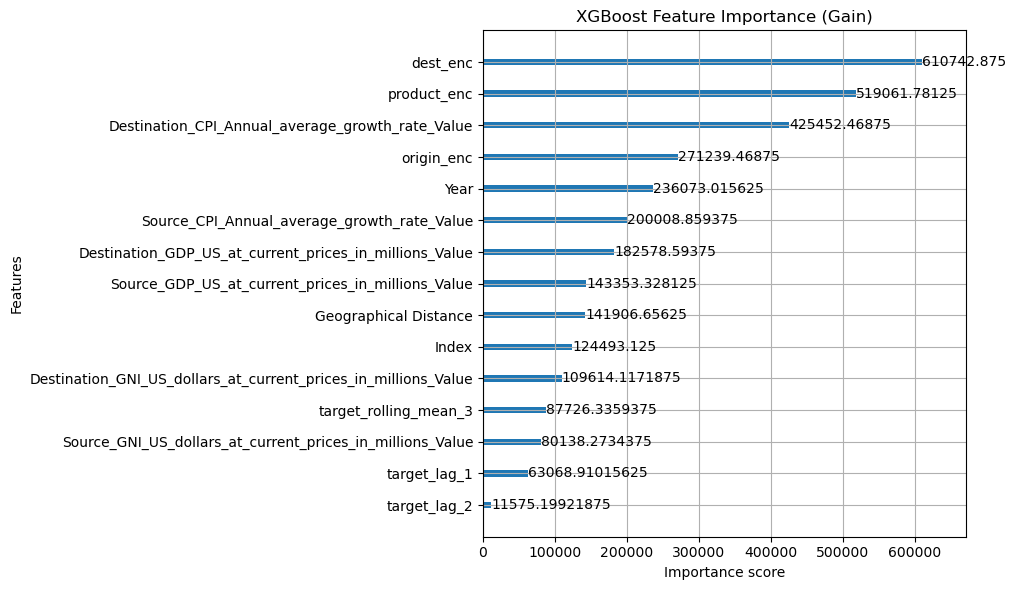

In [20]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

X_train = df_train[XGB_FEATURES]
y_train = df_train[TARGET]
X_test  = df_test[XGB_FEATURES]
y_test  = df_test[TARGET]

xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=30,
    eval_metric="mae",
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100,
)

y_pred_xgb = xgb_model.predict(X_test)

mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb   = r2_score(y_test, y_pred_xgb)

print(f"\nXGBoost Test Results:")
print(f"  MAE  : {mae_xgb:.4f}")
print(f"  RMSE : {rmse_xgb:.4f}")
print(f"  R²   : {r2_xgb:.4f}")

# Feature importance plot
fig, ax = plt.subplots(figsize=(10, 6))
xgb.plot_importance(xgb_model, max_num_features=15, ax=ax, importance_type="gain")
ax.set_title("XGBoost Feature Importance (Gain)")
plt.tight_layout()
plt.show()


## Step 4 — Temporal Fusion Transformer (TFT)

TFT requires:
- A `time_idx` integer column (0-based, continuous per group)
- A `group_id` column identifying each time-series
- Known future covariates (Year, product) and observed covariates (CPI, GDP, GNI, LSBCI, Distance)


In [25]:
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer, Baseline
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import MAE as TFT_MAE
import lightning.pytorch as pl
import torch

# ── 1. Build group_id + time_idx ─────────────────────────────────────────────
df_tft = df_model.copy()

# Unique series ID per (origin, destination, product)
df_tft["group_id"] = (
    df_tft["Origin_Label"].astype(str) + "|"
    + df_tft["Destination_Label"].astype(str) + "|"
    + df_tft["Product_Code"].astype(str)
)

# time_idx: 0-based integer index within each group
min_year = df_tft[TIME_COL].min()
df_tft["time_idx"] = df_tft[TIME_COL] - min_year

# ── 2. Filter out series that are too short ───────────────────────────────────
MIN_SERIES_LEN = 6
series_len = df_tft.groupby("group_id")["time_idx"].count()
long_series = series_len[series_len >= MIN_SERIES_LEN].index
df_tft = df_tft[df_tft["group_id"].isin(long_series)].reset_index(drop=True)

print(f"Series remaining after length filter: {df_tft['group_id'].nunique()}")
print(f"Total rows for TFT: {len(df_tft)}")

# ── 3. Prediction & encoder lengths ──────────────────────────────────────────
MAX_PREDICTION_LENGTH = 2   # predict 2 years ahead
MAX_ENCODER_LENGTH    = 4   # look-back window

max_time_idx = df_tft["time_idx"].max()
training_cutoff = max_time_idx - MAX_PREDICTION_LENGTH

# ── 4. Categorical columns must be strings ────────────────────────────────────
for col in ["group_id", "Product_Code"]:
    df_tft[col] = df_tft[col].astype(str)

# ── 5. Build TimeSeriesDataSet ─────────────────────────────────────────────────
training_dataset = TimeSeriesDataSet(
    df_tft[df_tft["time_idx"] <= training_cutoff],
    time_idx="time_idx",
    target=TARGET,
    group_ids=["group_id"],
    min_encoder_length=MAX_ENCODER_LENGTH // 2,
    max_encoder_length=MAX_ENCODER_LENGTH,
    min_prediction_length=1,
    max_prediction_length=MAX_PREDICTION_LENGTH,
    static_categoricals=["group_id", "Product_Code"],
    time_varying_known_reals=["time_idx"],
    time_varying_unknown_reals=FEATURE_COLS + [TARGET],
    target_normalizer=GroupNormalizer(groups=["group_id"], transformation="softplus"),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

validation_dataset = TimeSeriesDataSet.from_dataset(
    training_dataset,
    df_tft,
    predict=True,
    stop_randomization=True,
)

BATCH_SIZE = 64
train_loader = training_dataset.to_dataloader(train=True,  batch_size=BATCH_SIZE, num_workers=0)
val_loader   = validation_dataset.to_dataloader(train=False, batch_size=BATCH_SIZE, num_workers=0)

print("DataLoaders created.")


Series remaining after length filter: 25020
Total rows for TFT: 150120
DataLoaders created.


In [27]:
from pytorch_forecasting.metrics import QuantileLoss

pl.seed_everything(42)

tft_model = TemporalFusionTransformer.from_dataset(
    training_dataset,
    learning_rate=3e-3,
    hidden_size=32,
    attention_head_size=2,
    dropout=0.1,
    hidden_continuous_size=16,
    output_size=7,           # 7 quantiles: [0.02, 0.1, 0.25, 0.5, 0.75, 0.9, 0.98]
    loss=QuantileLoss(),
    log_interval=10,
    reduce_on_plateau_patience=4,
)

print(f"Number of parameters in TFT: {tft_model.size() / 1e3:.1f}k")

trainer = pl.Trainer(
    max_epochs=50,
    accelerator="auto",
    gradient_clip_val=0.1,
    enable_progress_bar=True,
    logger=False,
    enable_checkpointing=False,
)

trainer.fit(tft_model, train_dataloaders=train_loader, val_dataloaders=val_loader)


Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Number of parameters in TFT: 887.0k


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │  800 K │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    448 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  6.2 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 22.8 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  3.8 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  2.1 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     64 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  5.3 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  3.2 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    231 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 886 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 886 K                                                                                                
Total estimated model params size (MB): 3                                                                          
Modules in train mode: 404                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

c:\Users\xianj\anaconda3\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 
'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.

`Trainer.fit` stopped: `max_epochs=50` reached.


## Step 5 — TFT Evaluation


TFT Validation Results:
  MAE  : 3.8272
  RMSE : 22.2729
  R²   : 0.1238


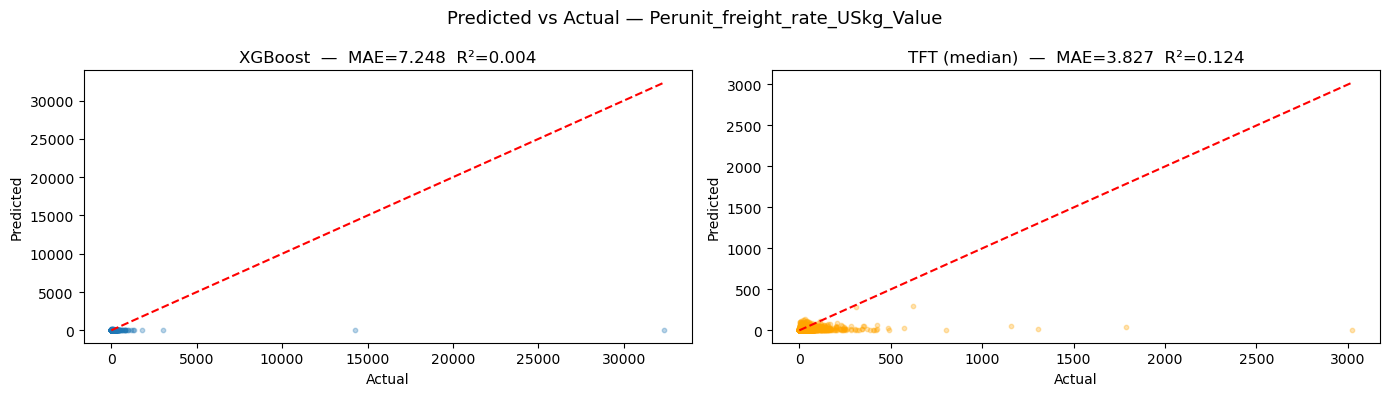

c:\Users\xianj\anaconda3\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\xianj\anaconda3\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


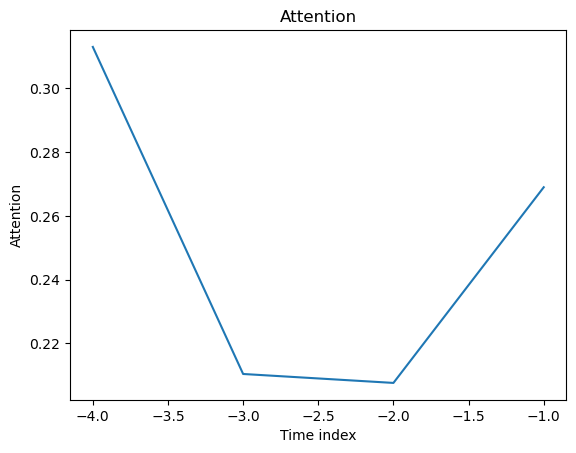

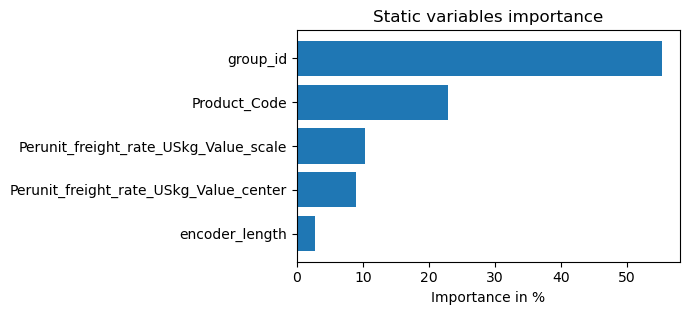

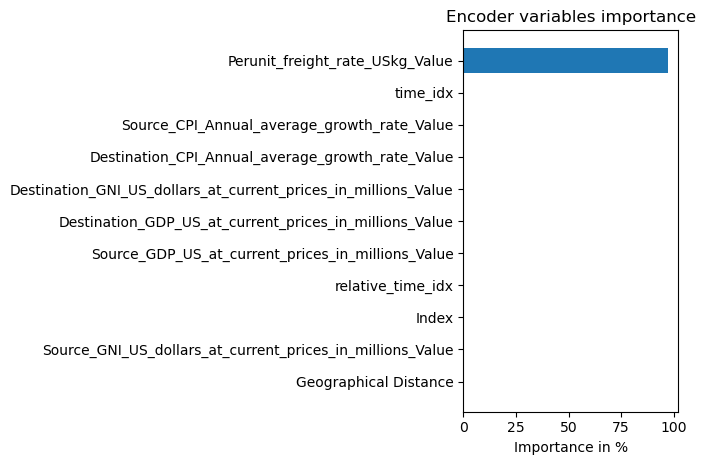

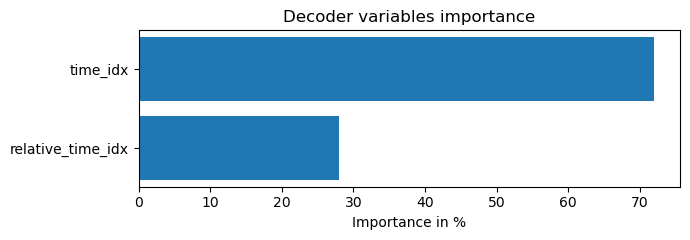

In [30]:
# ── Predictions on validation set ─────────────────────────────────────────────
# Use return_index=False to get just the prediction object, avoid unpacking issues
output = tft_model.predict(val_loader, mode="raw", return_index=False)

# In pytorch-forecasting 1.x the raw output may be a namedtuple or plain tensor
# Extract the prediction tensor
if hasattr(output, "prediction"):
    raw_preds = output.prediction          # shape: (N, horizon, n_quantiles)
else:
    raw_preds = output                     # fallback: already a tensor

# Extract median (quantile 0.5) — index 3 in the default 7-quantile output
y_pred_tft_median = raw_preds[:, :, 3].cpu().numpy().flatten()

# Get actuals from the validation loader
actuals_list = []
for x, y in val_loader:
    actuals_list.append(y[0] if isinstance(y, (list, tuple)) else y)
y_actuals = torch.cat(actuals_list).cpu().numpy().flatten()

# Trim to same length (validation may include padding)
min_len = min(len(y_pred_tft_median), len(y_actuals))
y_pred_tft_median = y_pred_tft_median[:min_len]
y_actuals         = y_actuals[:min_len]

mae_tft  = mean_absolute_error(y_actuals, y_pred_tft_median)
rmse_tft = np.sqrt(mean_squared_error(y_actuals, y_pred_tft_median))
r2_tft   = r2_score(y_actuals, y_pred_tft_median)

print("TFT Validation Results:")
print(f"  MAE  : {mae_tft:.4f}")
print(f"  RMSE : {rmse_tft:.4f}")
print(f"  R²   : {r2_tft:.4f}")

# ── Comparison plot ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(y_test, y_pred_xgb, alpha=0.3, s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
axes[0].set_title(f"XGBoost  —  MAE={mae_xgb:.3f}  R²={r2_xgb:.3f}")
axes[0].set_xlabel("Actual"); axes[0].set_ylabel("Predicted")

axes[1].scatter(y_actuals, y_pred_tft_median, alpha=0.3, s=10, color="orange")
axes[1].plot([y_actuals.min(), y_actuals.max()], [y_actuals.min(), y_actuals.max()], "r--")
axes[1].set_title(f"TFT (median)  —  MAE={mae_tft:.3f}  R²={r2_tft:.3f}")
axes[1].set_xlabel("Actual"); axes[1].set_ylabel("Predicted")

plt.suptitle("Predicted vs Actual — Perunit_freight_rate_USkg_Value", fontsize=13)
plt.tight_layout()
plt.show()

# ── TFT Attention / Variable importance ───────────────────────────────────────
# Re-run with return_index to get named output for interpretation
output_full = tft_model.predict(val_loader, mode="raw", return_index=False)
if hasattr(output_full, "prediction"):
    interpretation = tft_model.interpret_output(output_full, reduction="sum")
    tft_model.plot_interpretation(interpretation)
    plt.show()


## Step 6 — Future Freight Rate Forecast

Forecast `MAX_PREDICTION_LENGTH` years beyond the last observed year using both models.


In [34]:
# ── XGBoost future forecast (iterative 1-step-ahead) ─────────────────────────
future_years = list(range(max_year + 1, max_year + MAX_PREDICTION_LENGTH + 1))

# Use the last known row per group as the starting state
last_known = (
    df_model
    .sort_values(GROUP_COLS + [TIME_COL])
    .groupby(GROUP_COLS)
    .tail(1)
    .copy()
)

all_xgb_forecasts = []

for fwd_year in future_years:
    rows = last_known.copy()
    rows[TIME_COL] = fwd_year

    # Roll lags forward using previous predictions or last actuals
    rows["target_lag_1"] = last_known[TARGET]
    rows["target_lag_2"] = last_known.get("target_lag_1", last_known[TARGET])
    rows["target_lag_3"] = last_known.get("target_lag_2", last_known[TARGET])
    rows["target_rolling_mean_3"] = (
        rows[["target_lag_1", "target_lag_2", "target_lag_3"]].mean(axis=1)
    )

    X_fut = rows[XGB_FEATURES].fillna(rows[XGB_FEATURES].median(numeric_only=True))
    rows[TARGET] = xgb_model.predict(X_fut)
    rows["Year_label"] = fwd_year

    all_xgb_forecasts.append(rows[GROUP_COLS + ["Year_label", TARGET]].copy())
    last_known = rows  # feed predictions forward

df_xgb_forecast = pd.concat(all_xgb_forecasts, ignore_index=True)
df_xgb_forecast.rename(columns={TARGET: "XGB_Forecast"}, inplace=True)

print("XGBoost future forecast (first 10 rows):")
print(df_xgb_forecast.head(10))

# ── TFT future forecast ───────────────────────────────────────────────────────
tft_future_dataset = TimeSeriesDataSet.from_dataset(
    training_dataset,
    df_tft,
    predict=True,
    stop_randomization=True,
)
tft_future_loader = tft_future_dataset.to_dataloader(train=False, batch_size=BATCH_SIZE, num_workers=0)

tft_future_output = tft_model.predict(tft_future_loader, mode="raw", return_index=False)
if hasattr(tft_future_output, "prediction"):
    tft_raw_preds = tft_future_output.prediction
else:
    tft_raw_preds = tft_future_output

# Median quantile (index 3)
tft_median_forecast = tft_raw_preds[:, :, 3].cpu().numpy()

# ── Decode group_id → Origin, Destination, Product ────────────────────────────
# pytorch-forecasting's NaNLabelEncoder sorts group_ids alphabetically during fit,
# so predictions are ordered by sorted group_id string — reconstruct that ordering
# from df_tft (only groups present in the training split are included in the forecast)
forecast_group_ids = sorted(
    df_tft[df_tft["time_idx"] <= training_cutoff]["group_id"].unique()
)

# Lookup table: group_id string → (Origin, Destination, Product)
group_meta = (
    df_tft.drop_duplicates("group_id")
    .set_index("group_id")[["Origin_Label", "Destination_Label", "Product_Code"]]
)

n_preds  = len(tft_median_forecast)
n_groups = len(forecast_group_ids)
if n_preds != n_groups:
    print(f"Warning: {n_preds} predictions vs {n_groups} groups — trimming index to match.")
    forecast_group_ids = forecast_group_ids[:n_preds]

df_tft_forecast = pd.DataFrame(
    [group_meta.loc[g] for g in forecast_group_ids]
).reset_index(drop=True)

for step in range(MAX_PREDICTION_LENGTH):
    df_tft_forecast[f"TFT_Forecast_Year+{step+1}"] = tft_median_forecast[:, step]

print("\nTFT future forecast (first 5 rows):")
print(df_tft_forecast.head())

# ── Save forecasts ────────────────────────────────────────────────────────────
df_xgb_forecast.to_csv(f"{data_path}/xgb_freight_forecast.csv", index=False)
df_tft_forecast.to_csv(f"{data_path}/tft_freight_forecast.csv",  index=False)
print("\nForecasts saved to dataset/")


XGBoost future forecast (first 10 rows):
  Origin_Label Destination_Label  Product_Code  Year_label  XGB_Forecast
0  Afghanistan            Angola          9404        2022     18.926329
1  Afghanistan         Argentina          6109        2022      3.232965
2  Afghanistan         Argentina          8517        2022     27.137455
3  Afghanistan         Australia          2106        2022      1.079657
4  Afghanistan         Australia          6109        2022      1.755275
5  Afghanistan         Australia          8517        2022     29.989079
6  Afghanistan           Austria          3304        2022      1.465371
7  Afghanistan           Austria          6109        2022      6.380642
8  Afghanistan           Austria          8517        2022     32.059380
9  Afghanistan           Austria          9404        2022     28.816908


c:\Users\xianj\anaconda3\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\xianj\anaconda3\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.



TFT future forecast (first 5 rows):
  Origin_Label             Destination_Label Product_Code  \
0  Afghanistan                       Austria         6109   
1  Afghanistan                         Italy         8517   
2  Afghanistan  Netherlands (Kingdom of the)         8517   
3  Afghanistan          United Arab Emirates         8517   
4  Afghanistan      United States of America         8517   

   TFT_Forecast_Year+1  TFT_Forecast_Year+2  
0             1.703080             2.852497  
1             8.153221             9.295257  
2             4.098089             4.010092  
3             3.306428            11.461485  
4             6.770360             6.944236  

Forecasts saved to dataset/
